# Customer Segmentation Analysis — FMCG Loyalty Card Data

**Goal:** Segment 2,000 supermarket loyalty-card customers into meaningful groups, using three clustering methods that make progressively better use of the dataset's mixed numeric/categorical structure — and empirically justify which one actually performs best, rather than assuming it from theory alone.

**Dataset:** 2,000 anonymized FMCG customers, 7 features (demographic + socioeconomic), no missing values. Full variable dictionary in `data/segmentation_data_legend.xlsx`.

**Notebook structure:**
1. Data loading & quality check
2. Exploratory Data Analysis
3. Hypothesis testing (with assumption checks)
4. K-Means: choosing k (elbow + silhouette), fitting
5. K-Prototypes: choosing k (elbow + silhouette), fitting
6. K-Means vs. K-Prototypes — empirical comparison (not just theory)
7. Hierarchical clustering (Gower distance, linkage comparison, dendrogram)
8. Three-way comparison of all methods
9. Cluster profiling — business personas
10. PCA — visualization & multicollinearity check
11. Final report & recommendations


In [5]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram

from src.data_loader import load_raw, load_labeled, basic_quality_report, CATEGORICAL_COLS, NUMERIC_COLS
from src.stats_tests import chi_square_test, two_group_test, one_way_anova, pearson_correlation
from src.clustering import (
    prepare_kmeans_input, prepare_kprototypes_input,
    elbow_and_silhouette_kmeans, cost_kprototypes, elbow_and_silhouette_kprototypes,
    run_kmeans, run_kprototypes, compare_clusterings,
    compute_gower_matrix, gower_silhouette, categorical_purity, numeric_separation, empirical_comparison,
    hierarchical_linkage, cophenetic_correlation, cut_tree, elbow_and_silhouette_hierarchical,
    pca_2d, profile_clusters
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Data Loading & Quality Check

Two dataframe versions are kept throughout: `df_raw` (integer-coded categoricals, needed by all clustering algorithms) and `df_labeled` (human-readable categories, needed for EDA and profiling).

In [6]:
df_raw = load_raw("../data/segmentation_data.csv")
df_labeled = load_labeled("../data/segmentation_data.csv")

report = basic_quality_report(df_raw)
print(f"Rows: {report['n_rows']}, Columns: {report['n_cols']}")
print(f"Duplicate IDs: {report['duplicate_ids']}")
print(f"Missing values per column: {report['missing_values']}")

df_labeled.head()


Rows: 2000, Columns: 8
Duplicate IDs: 0
Missing values per column: {'ID': 0, 'Sex': 0, 'Marital status': 0, 'Age': 0, 'Education': 0, 'Income': 0, 'Occupation': 0, 'Settlement size': 0}


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,male,single,67,university,124670,skilled employee,big city
1,100000002,female,non-single,22,high school,150773,skilled employee,big city
2,100000003,male,single,49,high school,89210,unemployed/unskilled,small city
3,100000004,male,single,45,high school,171565,skilled employee,mid-sized city
4,100000005,male,single,53,high school,149031,skilled employee,mid-sized city


## 2. Exploratory Data Analysis

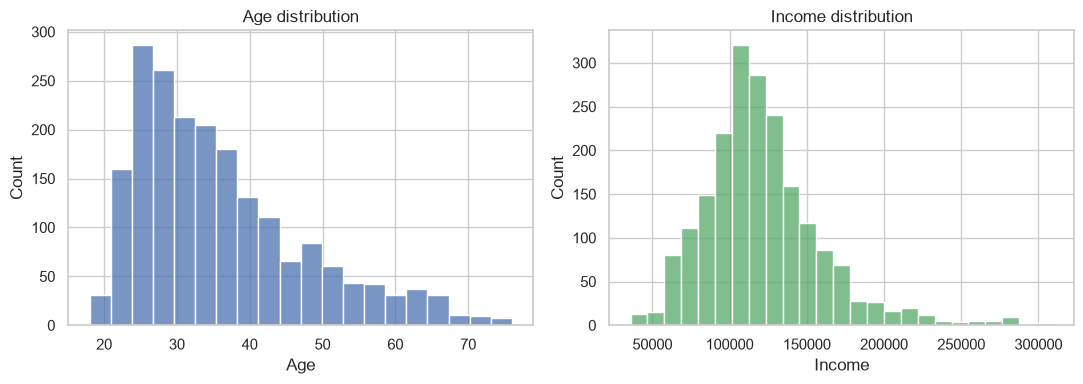

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_raw["Age"], bins=20, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age distribution")
sns.histplot(df_raw["Income"], bins=25, ax=axes[1], color="#55A868")
axes[1].set_title("Income distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/01_numeric_distributions.png", bbox_inches="tight")
plt.show()


## Observations
### Age Distribution
The age distribution is positively skewed, with the majority of customers falling between 20 and 50 years of age. The frequency gradually decreases for older age groups, indicating that there are relatively fewer customers above age 50. This suggests that the dataset is dominated by young and middle-aged customers.

### Income Distribution
The income distribution is positively skewed, with the majority of customers having income between 80,000 and 1,40,000 . Only a small proportion belong to the high income category.

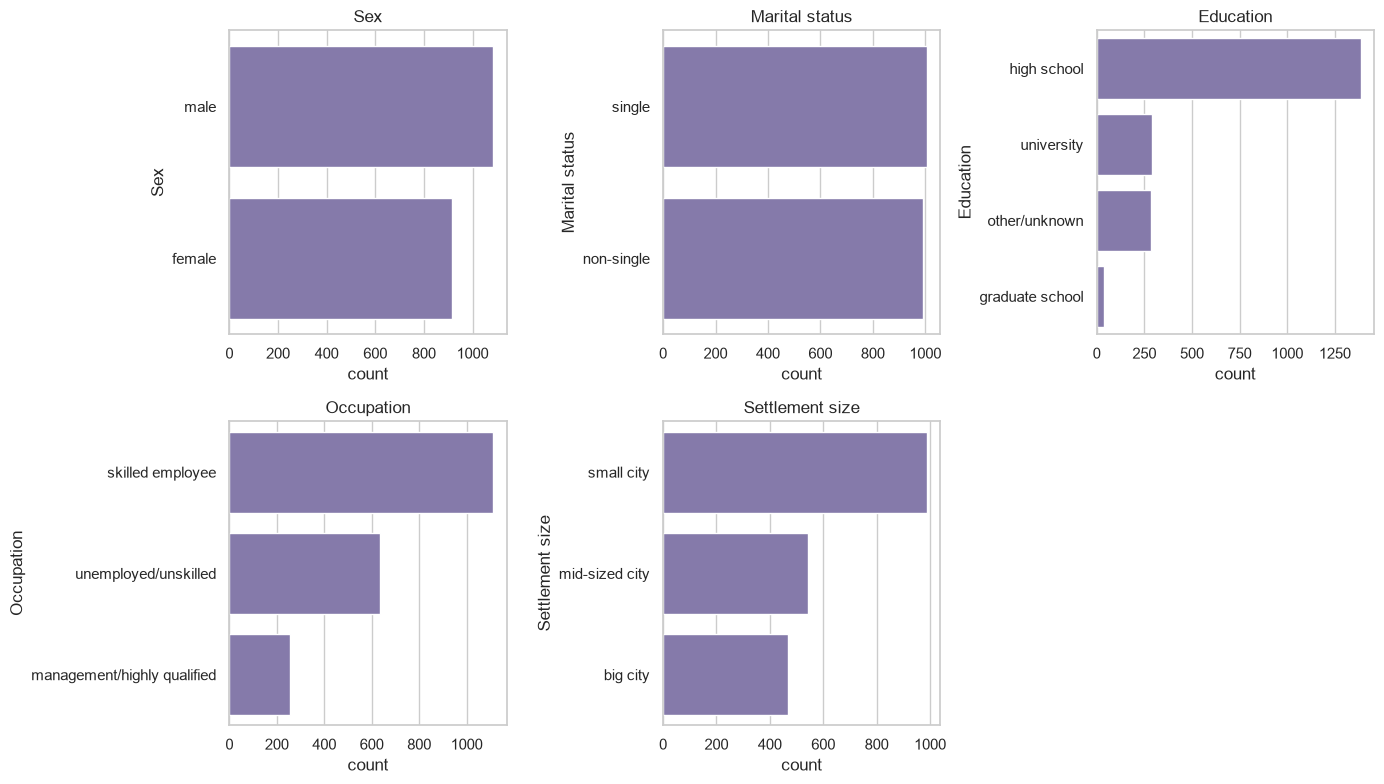

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_COLS):
    order = df_labeled[col].value_counts().index
    sns.countplot(data=df_labeled, y=col, order=order, ax=axes[i], color="#8172B2")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/02_categorical_distributions.png", bbox_inches="tight")
plt.show()


## Observations
### Sex
The dataset contains nearly a balanced distribution of male and female customers.

### Marital Status
Also the proportions of single customers with non-single customers is almost equal.

### Education
The majority of customers have completed high school education, followed by University education.A comparatively smaller proportions belong to the Other category and Graduate school being the smallest group. This indicates that the dataset is dominated by customers with high school educational background.

### Occupation
Most of the customers are Employees, followed by Unemployed individuals, whereas the Management category constitutes the smallest proportion. This indicates that the employment status may influence customer segmentation and purchasing behaviour.

### Settlement Size
Nearly half of the customers reside in the small cities, while the remaining customers reside in mid-sized and large cities. This suggests that the customer base in concentrated in smaller urban areas, with comparatively fewer customers from larger cities.


C:\Users\User\AppData\Local\Temp\ipykernel_9352\3364820844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_9352\3364820844.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(
C:\Users\User\AppData\Local\Temp\ipykernel_9352\3364820844.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_9352\3364820844.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks ma

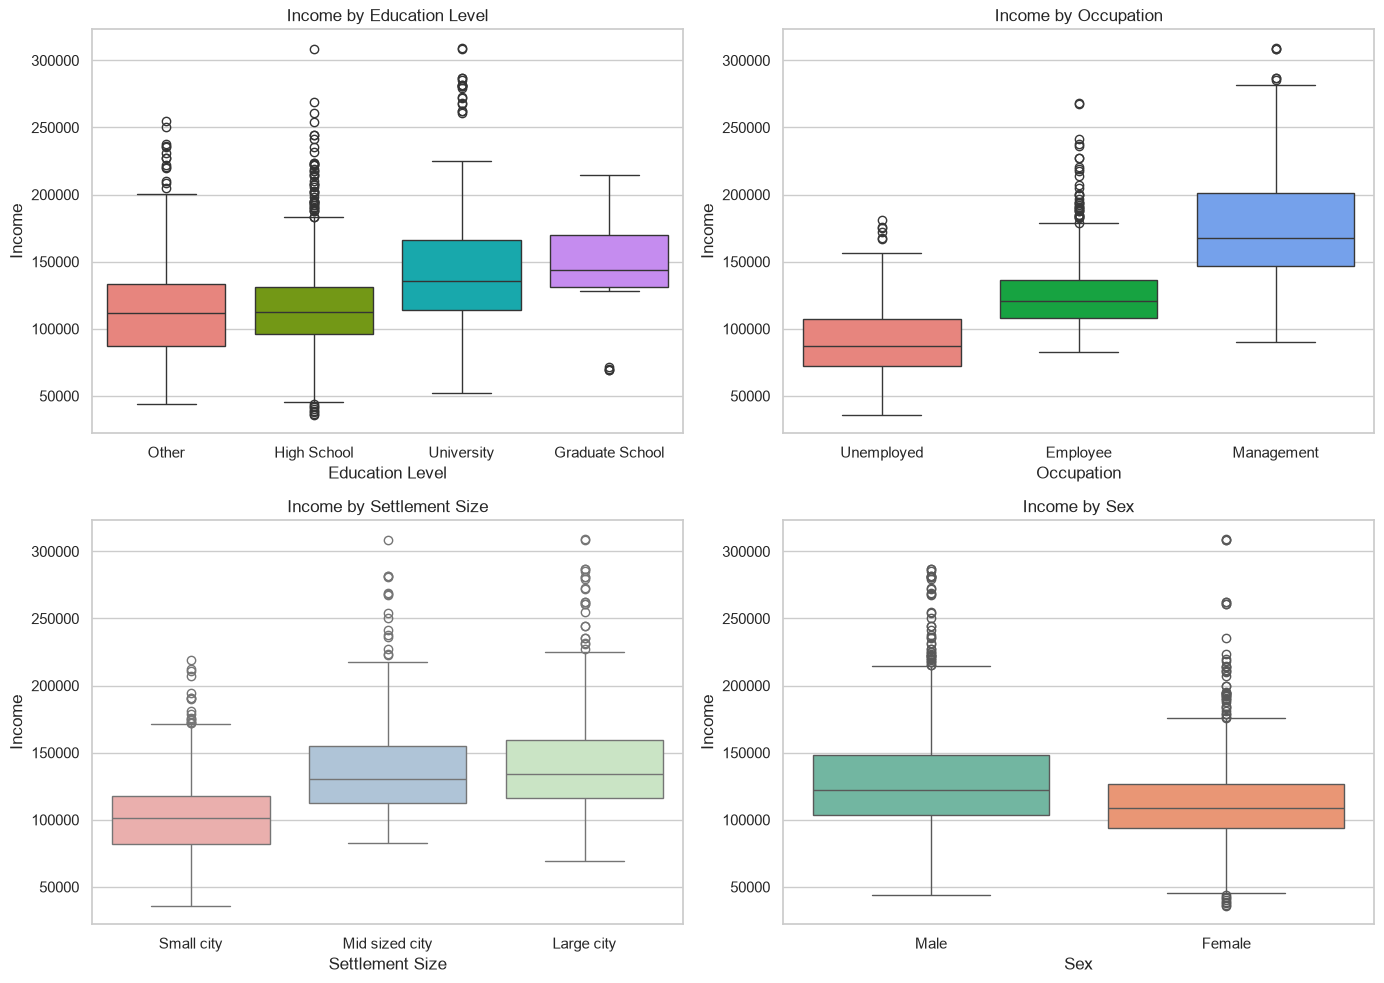

C:\Users\User\AppData\Local\Temp\ipykernel_9352\3364820844.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


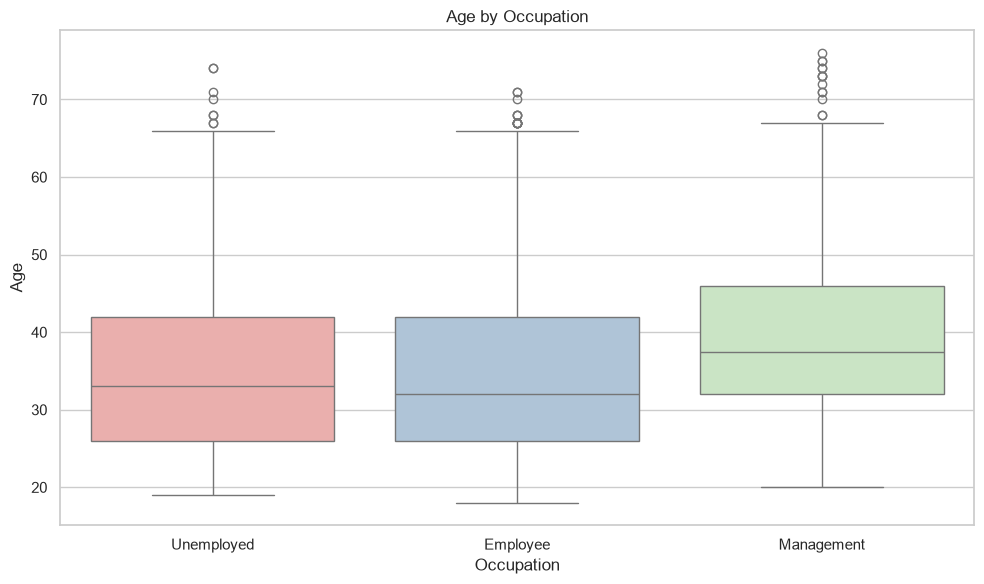

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Income by Education
edu_colors = ["#F8766D", "#7CAE00", "#00BFC4", "#C77CFF"]

sns.boxplot(
    data=df_labeled,
    x="Education",
    y="Income",
    order=["other/unknown", "high school", "university", "graduate school"],
    palette=edu_colors,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Income by Education Level")
axes[0, 0].set_xlabel("Education Level")
axes[0, 0].set_ylabel("Income")
axes[0, 0].set_xticklabels(
    ["Other", "High School", "University", "Graduate School"],
    rotation=0
)


# 2. Income by Occupation
occ_colors = ["#F8766D", "#00BA38", "#619CFF"]

sns.boxplot(
    data=df_labeled,
    x="Occupation",
    y="Income",
    order=["unemployed/unskilled",
           "skilled employee",
           "management/highly qualified"],
    palette=occ_colors,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Income by Occupation")
axes[0, 1].set_xlabel("Occupation")
axes[0, 1].set_ylabel("Income")
axes[0, 1].set_xticklabels(
    ["Unemployed", "Employee", "Management"]
)


# 3. Income by Settlement Size
settlement_colors = ["#F4A6A3", "#A9C4DD", "#C7E9C0"]

sns.boxplot(
    data=df_labeled,
    x="Settlement size",
    y="Income",
    order=["small city", "mid-sized city", "big city"],
    palette=settlement_colors,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Income by Settlement Size")
axes[1, 0].set_xlabel("Settlement Size")
axes[1, 0].set_ylabel("Income")
axes[1, 0].set_xticklabels(
    ["Small city", "Mid sized city", "Large city"]
)


# 4. Income by Sex
sex_colors = ["#66C2A5", "#FC8D62"]

sns.boxplot(
    data=df_labeled,
    x="Sex",
    y="Income",
    palette=sex_colors,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Income by Sex")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].set_ylabel("Income")
axes[1, 1].set_xticklabels(["Male", "Female"])

plt.tight_layout()
plt.savefig("../outputs/figures/income_boxplots.png", dpi=300)
plt.show()


# -------------------------------
# Figure 2: Age by Occupation
# -------------------------------
plt.figure(figsize=(10, 6))

age_colors = ["#F4A6A3", "#A9C4DD", "#C7E9C0"]

sns.boxplot(
    data=df_labeled,
    x="Occupation",
    y="Age",
    order=["unemployed/unskilled",
           "skilled employee",
           "management/highly qualified"],
    palette=age_colors
)

plt.title("Age by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Age")
plt.xticks(
    [0, 1, 2],
    ["Unemployed", "Employee", "Management"]
)

plt.tight_layout()
plt.savefig("../outputs/figures/age_by_occupation.png", dpi=300)
plt.show()

## Observations
### Income by Education Level
Customers with higher educational qualification tend to have higher median incomes. Several outleirs are observed among university and high school customers.
### Income by Occupation
Management professionals have the highest median income, followed by employees. this indicates that occupation is strongly associated with customer income.
### Income by Settlement Size
Customers residing in mid-sized and large cities generally have higher income than those residing in small cities. This indicates that the purchasing capacity of customers are influenced by settlement size.
### Income by Sex
Male customers have slightly higher median income than female customers. However, both the groups show overlap in their income distributions, indicating that similar income variation exists in both groups.
### Age by Occupation
Customers in management positions tends to be older than employees and unemployed individuals, suggesting that occupational categories differ with respect to the customers’ age.

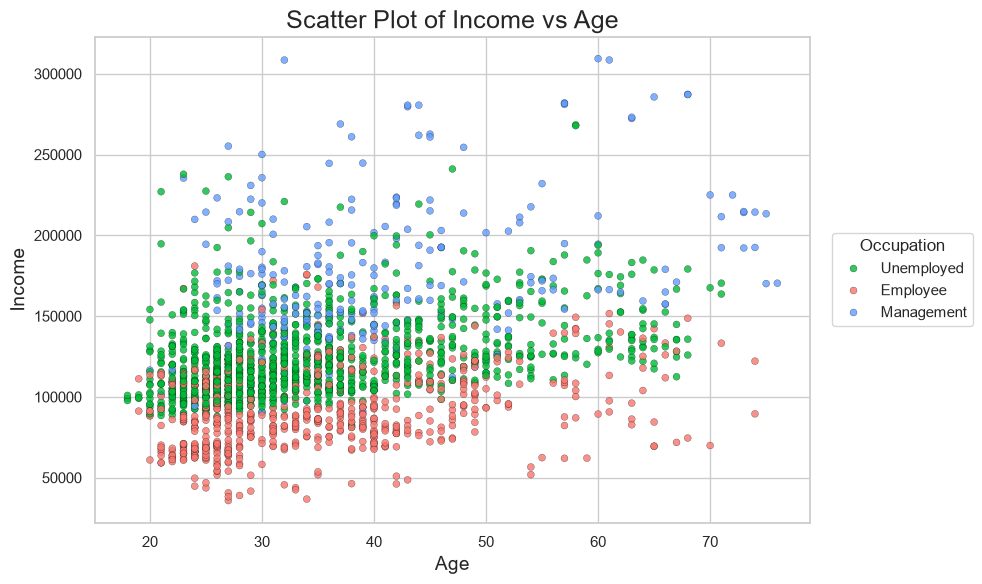

Pearson correlation between Age and Income: 0.341


In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_labeled,
    x="Age",
    y="Income",
    hue="Occupation",
    palette={
        "unemployed/unskilled": "#F8766D",
        "skilled employee": "#00BA38",
        "management/highly qualified": "#619CFF"
    },
    alpha=0.8,
    s=25,
    edgecolor="black",
    linewidth=0.2
)

plt.title("Scatter Plot of Income vs Age", fontsize=18)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Income", fontsize=14)

# Rename legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=["Unemployed", "Employee", "Management"],
    title="Occupation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig("../outputs/figures/income_vs_age_scatter.png", dpi=300)
plt.show()

# Pearson correlation between Age and Income
corr = df_labeled["Age"].corr(df_labeled["Income"])

print(f"Pearson correlation between Age and Income: {corr:.3f}")

## Observations
### Scatterplot of Income vs Age
The scatter plot indicates a moderate positive relationship between age and income.
The Pearson correlation between Age and Income is 0.341, indicating a moderate positive association.
Customers in management occupations tend to have higher income across all the age groups.

## 3. Statistical Hypothesis Testing

Each test below checks its own assumptions (normality via Shapiro-Wilk, equal variance via Levene's test) and automatically falls back to the appropriate non-parametric alternative when an assumption is violated, rather than blindly applying a parametric test.

In [12]:
from scipy.stats import shapiro

def shapiro_by_group(df, response, group):
    print(f"\nShapiro-Wilk Test: {response} by {group}")

    for g in df[group].unique():
        stat, p = shapiro(df[df[group] == g][response])

        print(f"{g:25} W = {stat:.4f}, p = {p:.4e}")


from scipy.stats import levene

def levene_test(df, response, group):

    samples = [g[response].values for _, g in df.groupby(group)]

    stat, p = levene(*samples)

    print(f"\nLevene's Test: {response} by {group}")
    print(f"Statistic = {stat:.3f}")
    print(f"p-value   = {p:.4e}")

    return stat, p

In [13]:
# Income vs Education
shapiro_by_group(df_labeled, "Income", "Education")
levene_test(df_labeled, "Income", "Education")

# Income vs Occupation
shapiro_by_group(df_labeled, "Income", "Occupation")
levene_test(df_labeled, "Income", "Occupation")

# Income vs Settlement Size
shapiro_by_group(df_labeled, "Income", "Settlement size")
levene_test(df_labeled, "Income", "Settlement size")

# Income vs Sex
shapiro_by_group(df_labeled, "Income", "Sex")
levene_test(df_labeled, "Income", "Sex")

# Age vs Occupation
shapiro_by_group(df_labeled, "Age", "Occupation")
levene_test(df_labeled, "Age", "Occupation")


Shapiro-Wilk Test: Income by Education
university                W = 0.9135, p = 6.5475e-12
high school               W = 0.9558, p = 4.6918e-20
other/unknown             W = 0.9363, p = 8.8050e-10
graduate school           W = 0.8993, p = 3.2731e-03

Levene's Test: Income by Education
Statistic = 16.900
p-value   = 7.6848e-11

Shapiro-Wilk Test: Income by Occupation
skilled employee          W = 0.9001, p = 2.6015e-26
unemployed/unskilled      W = 0.9743, p = 4.3816e-09
management/highly qualified W = 0.9397, p = 1.0490e-08

Levene's Test: Income by Occupation
Statistic = 65.054
p-value   = 4.2614e-28

Shapiro-Wilk Test: Income by Settlement size
big city                  W = 0.8910, p = 1.0941e-17
small city                W = 0.9781, p = 4.9495e-11
mid-sized city            W = 0.8947, p = 7.4185e-19

Levene's Test: Income by Settlement size
Statistic = 25.069
p-value   = 1.7672e-11

Shapiro-Wilk Test: Income by Sex
male                      W = 0.9417, p = 2.9772e-20
female       

(np.float64(1.1097486667039445), np.float64(0.32984500153993707))

## 5.3 Statistical Assumption Checking

Before selecting the appropriate statistical tests, the assumptions required for parametric methods were evaluated. Specifically, the **Shapiro–Wilk test** was used to assess the normality of the response variable within each group, while **Levene's test** was performed to examine the homogeneity of variances across groups.

### Shapiro–Wilk Test for Normality

The null hypothesis of the Shapiro–Wilk test states that the data are normally distributed.

**Null Hypothesis ($H_0$):** The response variable follows a normal distribution within each group.

**Alternative Hypothesis ($H_1$):** The response variable is not normally distributed within at least one group.

The Shapiro–Wilk test was conducted for the following comparisons:

- Income by Education
- Income by Occupation
- Income by Settlement Size
- Income by Sex
- Age by Occupation

For every group in each comparison, the obtained **p-values were less than 0.05**, indicating significant departures from normality. Therefore, the null hypothesis of normality was rejected for all cases.

**Observation:** The distributions of both **Income** and **Age** are not normally distributed within their respective demographic groups.

---

### Levene's Test for Homogeneity of Variances

Levene's test was used to evaluate whether the variances of the response variable were equal across groups.

**Null Hypothesis ($H_0$):** The variances are equal across all groups.

**Alternative Hypothesis ($H_1$):** At least one group has a different variance.

The results are summarized below.

| Response Variable | Grouping Variable | p-value | Interpretation |
|-------------------|------------------|---------|----------------|
| Income | Education | 7.68 × 10⁻¹¹ | Variances not equal |
| Income | Occupation | 4.26 × 10⁻²⁸ | Variances not equal |
| Income | Settlement Size | 1.77 × 10⁻¹¹ | Variances not equal |
| Income | Sex | 4.20 × 10⁻⁶ | Variances not equal |
| Age | Occupation | 0.330 | Variances are equal |

The results indicate that the assumption of homogeneity of variances was violated for all **Income** comparisons, whereas **Age across Occupation** satisfied the equal variance assumption.

---

### Choice of Statistical Tests

Since the **Shapiro–Wilk test indicated non-normality** for all comparisons (p < 0.05), the assumptions required for parametric tests such as the independent samples t-test and one-way ANOVA were not satisfied. Consequently, non-parametric statistical methods were employed throughout the analysis.

The following tests were selected:

- **Kruskal–Wallis rank-sum test** for comparing a continuous variable across three or more independent groups.
- **Wilcoxon rank-sum (Mann–Whitney U) test** for comparing a continuous variable between two independent groups.
- **Dunn's post-hoc test with Bonferroni correction** was performed whenever the Kruskal–Wallis test indicated a statistically significant difference to identify the specific groups that differed.

### Hypotheses

For each non-parametric comparison, the following hypotheses were tested.

**Null Hypothesis ($H_0$):** There is no significant difference in the distribution of the response variable among the groups.

**Alternative Hypothesis ($H_1$):** At least one group differs significantly in the distribution of the response variable.

In [14]:
from scipy.stats import kruskal, mannwhitneyu

def kruskal_test(df, response, group):
    """
    Performs Kruskal-Wallis test.

    Parameters
    ----------
    df : DataFrame
    response : str
        Continuous variable
    group : str
        Grouping variable

    Returns
    -------
    dict
    """

    groups = [g[response].values for _, g in df.groupby(group)]

    stat, p = kruskal(*groups)

    return {
        "test": "Kruskal-Wallis",
        "variables": f"{response} ~ {group}",
        "statistic": stat,
        "p_value": p,
        "significant": p < 0.05
    }

def mann_whitney_test(df, response, group):
    """
    Performs Mann-Whitney U Test.
    """

    groups = df[group].unique()

    g1 = df[df[group] == groups[0]][response]
    g2 = df[df[group] == groups[1]][response]

    stat, p = mannwhitneyu(
        g1,
        g2,
        alternative="two-sided"
    )

    return {
        "test": "Mann-Whitney U",
        "variables": f"{response} ~ {group}",
        "statistic": stat,
        "p_value": p,
        "significant": p < 0.05
    }

In [15]:
results = []

# Income vs Education
results.append(
    kruskal_test(df_labeled,
                 "Income",
                 "Education")
)

# Income vs Occupation
results.append(
    kruskal_test(df_labeled,
                 "Income",
                 "Occupation")
)

# Income vs Settlement Size
results.append(
    kruskal_test(df_labeled,
                 "Income",
                 "Settlement size")
)

# Income vs Sex
results.append(
    mann_whitney_test(df_labeled,
                      "Income",
                      "Sex")
)

# Age vs Occupation
results.append(
    kruskal_test(df_labeled,
                 "Age",
                 "Occupation")
)

In [16]:
summary = pd.DataFrame([
    {
        "Response Variable": r["variables"].split(" ~ ")[0],
        "Grouping Variable": r["variables"].split(" ~ ")[1],
        "Test Used": r["test"],
        "Test Statistic": round(r["statistic"], 3),
        "p-value": f"{r['p_value']:.2e}",
        "Decision": "Reject H₀" if r["significant"] else "Fail to Reject H₀"
    }
    for r in results
])

summary

,Response Variable,Grouping Variable,Test Used,Test Statistic,p-value,Decision
0,Income,Education,Kruskal-Wallis,142.115,1.32e-30,Reject H₀
1,Income,Occupation,Kruskal-Wallis,945.866,4.05e-206,Reject H₀
2,Income,Settlement size,Kruskal-Wallis,622.180,7.86e-136,Reject H₀
3,Income,Sex,Mann-Whitney U,617185.500,5.67e-21,Reject H₀
4,Age,Occupation,Kruskal-Wallis,58.823,1.69e-13,Reject H₀


## Post-hoc Analysis (Dunn’s Test)
Since the **Kruskal–Wallis test** indicated **significant differences** among groups for **Income vs Education, Income vs Occupation, Income vs Settlement Size,** and **Age vs Occupation**, **Dunn’s multiple comparison test with Bonferroni adjustment** was performed to identify the specific groups responsible for these differences.

In [17]:
pip install scikit-posthocs


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [21]:
import scikit_posthocs as sp

# Income vs Education
dunn_edu = sp.posthoc_dunn(
    df_labeled,
    val_col="Income",
    group_col="Education",
    p_adjust="bonferroni"
)

dunn_edu


,graduate school,high school,other/unknown,university
graduate school,1.000000e+00,4.824675e-07,1.940341e-07,1.000000e+00
high school,4.824675e-07,1.000000e+00,1.000000e+00,6.420157e-25
other/unknown,1.940341e-07,1.000000e+00,1.000000e+00,1.580317e-18
university,1.000000e+00,6.420157e-25,1.580317e-18,1.000000e+00


The post-hoc Dunn’s test showed that:

- There was no significant difference between Other and High School (adjusted p = 1.000).

- University differed significantly from Other and High School (adjusted p < 0.001).

- Graduate School differed significantly from Other and High School (adjusted p < 0.001).

- There was no significant difference between University and Graduate School (adjusted p = 1.000).

These results indicate that customers with University and Graduate School education have significantly different income levels compared to those with Other and High School education, whereas income does not differ significantly within these two pairs.

In [22]:
# Income vs Occupation
dunn_occ = sp.posthoc_dunn(
    df_labeled,
    val_col="Income",
    group_col="Occupation",
    p_adjust="bonferroni"
)
dunn_occ

,management/highly qualified,skilled employee,unemployed/unskilled
management/highly qualified,1.000000e+00,2.167967e-46,6.950816e-179
skilled employee,2.167967e-46,1.000000e+00,7.154985e-112
unemployed/unskilled,6.950816e-179,7.154985e-112,1.000000e+00


The post-hoc Dunn’s test revealed significant differences between all occupation groups.

- Unemployed vs Employee: adjusted p < 0.001

- Unemployed vs Management: adjusted p < 0.001

- Employee vs Management: adjusted p < 0.001

Thus, income differs significantly among Unemployed, Employee, and Management groups

In [23]:
# Income vs Settlement Size
dunn_settlement = sp.posthoc_dunn(
    df_labeled,
    val_col="Income",
    group_col="Settlement size",
    p_adjust="bonferroni"
)
dunn_settlement

,big city,mid-sized city,small city
big city,1.000000e+00,2.308090e-01,2.053618e-96
mid-sized city,2.308090e-01,1.000000e+00,1.788062e-87
small city,2.053618e-96,1.788062e-87,1.000000e+00


The post-hoc Dunn’s test indicated that:

- Small city differed significantly from Mid-sized city (adjusted p < 0.001).

- Small city differed significantly from Large city (adjusted p < 0.001).

- There was no significant difference between Mid-sized city and Large city (adjusted p = 0.231).

This suggests that customers from Small cities have significantly different income levels from those in Mid-sized and Large cities, while the latter two groups have similar income distributions.

In [24]:
# Age vs Occupation
dunn_age = sp.posthoc_dunn(
    df_labeled,
    val_col="Age",
    group_col="Occupation",
    p_adjust="bonferroni"
)
dunn_age

,management/highly qualified,skilled employee,unemployed/unskilled
management/highly qualified,1.000000e+00,1.302674e-13,1.024861e-10
skilled employee,1.302674e-13,1.000000e+00,1.000000e+00
unemployed/unskilled,1.024861e-10,1.000000e+00,1.000000e+00


The post-hoc Dunn’s test showed that:

- There was no significant difference between Unemployed and Employee (adjusted p = 0.510).

- Management differed significantly from Unemployed (adjusted p < 0.001).

- Management differed significantly from Employee (adjusted p < 0.001).

Therefore, customers in the Management category are significantly older than those in the Unemployed and Employee categories, while there is no significant age difference between the latter two groups.

## 4. K-Means — Choosing k, then Fitting

K-means clustering was applied to identify distinct customer segments based on the available customer characteristics. Although the dataset contains categorical variables, they were numerically encoded prior to clustering and the variables were standardized to ensure that variables measured on different scales contributed equally to the clustering process. The algorithm partitions observations into groups by minimizing the within-cluster sum of squares using Euclidean distance. Although the dataset contains categorical variables that are numerically encoded before clustering, K-means is applied to identify meaningful customer segments based on similarities in customer characteristics. The resulting clusters provide useful insights into customer behaviour and demographic patterns.

### 4.1 Choosing k: elbow (inertia) + silhouette, compared

K-Means input: 16 dimensions total (2 numeric + 14 one-hot categorical)


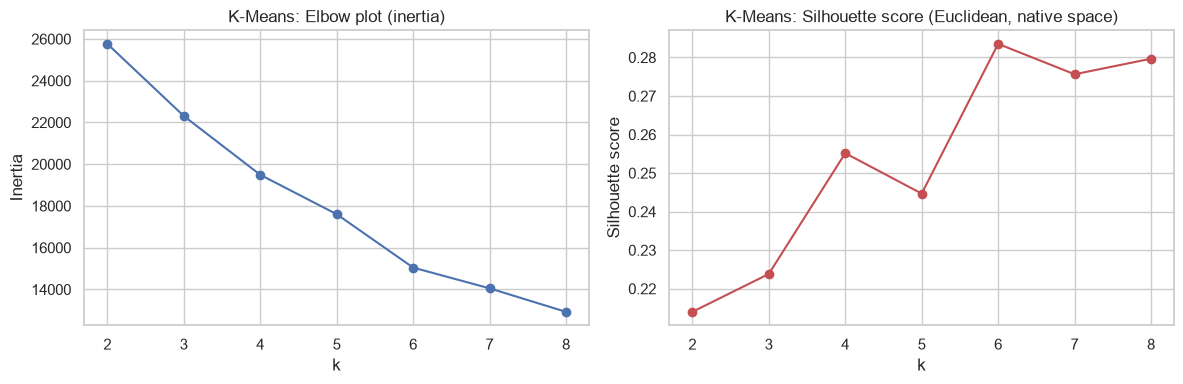

,k,inertia,silhouette
0,2,25765.378002,0.213981
1,3,22310.069113,0.223819
2,4,19491.996665,0.255162
3,5,17604.101609,0.244669
4,6,15045.947051,0.283527
5,7,14052.203629,0.275637
6,8,12924.941017,0.279678


In [29]:
X_kmeans, kmeans_feature_names = prepare_kmeans_input(df_raw)
print(f"K-Means input: {X_kmeans.shape[1]} dimensions total "
      f"(2 numeric + {X_kmeans.shape[1]-2} one-hot categorical)")

elbow_km = elbow_and_silhouette_kmeans(X_kmeans, k_range=range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_km["k"], elbow_km["inertia"], marker="o")
axes[0].set_title("K-Means: Elbow plot (inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(elbow_km["k"], elbow_km["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("K-Means: Silhouette score (Euclidean, native space)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/figures/04_kmeans_elbow_silhouette.png", bbox_inches="tight")
plt.show()

elbow_km


**Reading the two diagnostics together:** k=6 achieves a marginally higher silhouette score, but the non-monotonic pattern around k=5–6 suggests this may not reflect stable underlying structure. k=4 is chosen for a more robust elbow/silhouette agreement, interpretability, and consistency with the other two clustering methods used later in this project.

In [30]:
K = 4
labels_kmeans = run_kmeans(X_kmeans, K)
df_labeled["Cluster_KMeans"] = labels_kmeans
pd.Series(labels_kmeans).value_counts().sort_index().rename("cluster size")


0    770
1    616
2    287
3    327
Name: cluster size, dtype: int64

In [32]:
# ---- Cluster profiling ----
profile_kmeans = profile_clusters(df_labeled, labels_kmeans)
profile_kmeans

,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,0,770,38.5,29.0,106093.7,female (89.6%),non-single (84.4%),high school (100.0%),skilled employee (57.3%),small city (71.2%)
1,1,616,30.8,38.7,129210.2,male (98.7%),single (81.3%),high school (100.0%),skilled employee (57.6%),mid-sized city (36.2%)
2,2,287,14.3,27.4,115068.2,male (88.9%),single (100.0%),other/unknown (100.0%),skilled employee (58.5%),small city (47.4%)
3,3,327,16.4,54.3,145561.5,female (56.3%),non-single (69.7%),university (89.0%),skilled employee (45.6%),small city (40.1%)


**Table: Summary of Customer Cluster Profiles (K-Means, k=4)**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| 0 | Youngest customers, predominantly female, non-single, high-school education, skilled employees, small city | Young, budget-conscious customers |
| 1 | Older customers, predominantly male, mostly single, high-school education, skilled employees, spread across city sizes | Established single professionals |
| 2 | Youngest male-dominated group, entirely single, unspecified/other education, skilled employees, small city | Young single customers, niche segment |
| 3 | Oldest customers, more balanced across sex, non-single, university-educated, mixed occupations, small city | Affluent, highly educated customers |

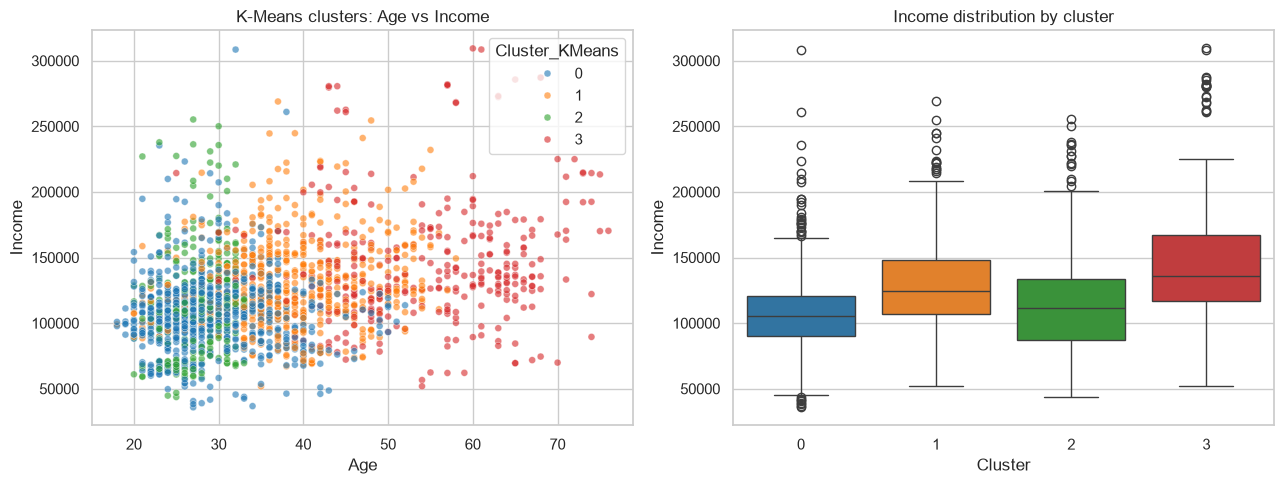

In [34]:
# ---- Cluster visualization 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df_labeled, x="Age", y="Income",
    hue="Cluster_KMeans", palette="tab10", alpha=0.6, s=25, ax=axes[0]
)
axes[0].set_title("K-Means clusters: Age vs Income")

sns.boxplot(
    data=df_labeled, x="Cluster_KMeans", y="Income",
    hue="Cluster_KMeans", palette="tab10", legend=False, ax=axes[1]
)
axes[1].set_title("Income distribution by cluster")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_cluster_visualization.png", bbox_inches="tight")
plt.show()

**Observation — Age vs Income scatter:**
The four clusters show partial but not clean separation in Age-Income space. Cluster 0 (blue) is tightly packed in the young, lower-income region, and Cluster 3 (red) skews toward older, higher-income points — consistent with the profile table. However, Clusters 1 (orange) and 2 (green) overlap substantially with each other and with the edges of Cluster 0 across most of the Age range, since their separation is driven more by Sex and Marital status than by Age or Income. This confirms the earlier point: K-Means's cluster boundaries here are shaped more by categorical variables than by the two numeric ones, so a purely numeric 2D view understates how the clusters were actually formed.

**Observation — Income distribution by cluster:**
Median income increases in the expected order (Cluster 0 < Cluster 2 < Cluster 1 < Cluster 3), consistent with the profile table's mean-income ranking. All four clusters show a long right tail of high-income outliers, most visibly in Clusters 0 and 3 — meaning even the "lowest income" and "highest income" clusters aren't cleanly separated by income alone; there's real overlap in the interquartile ranges between Clusters 0, 1, and 2. Cluster 3 is the most distinctly separated on income, with a visibly higher median and narrower relative spread than the other three.

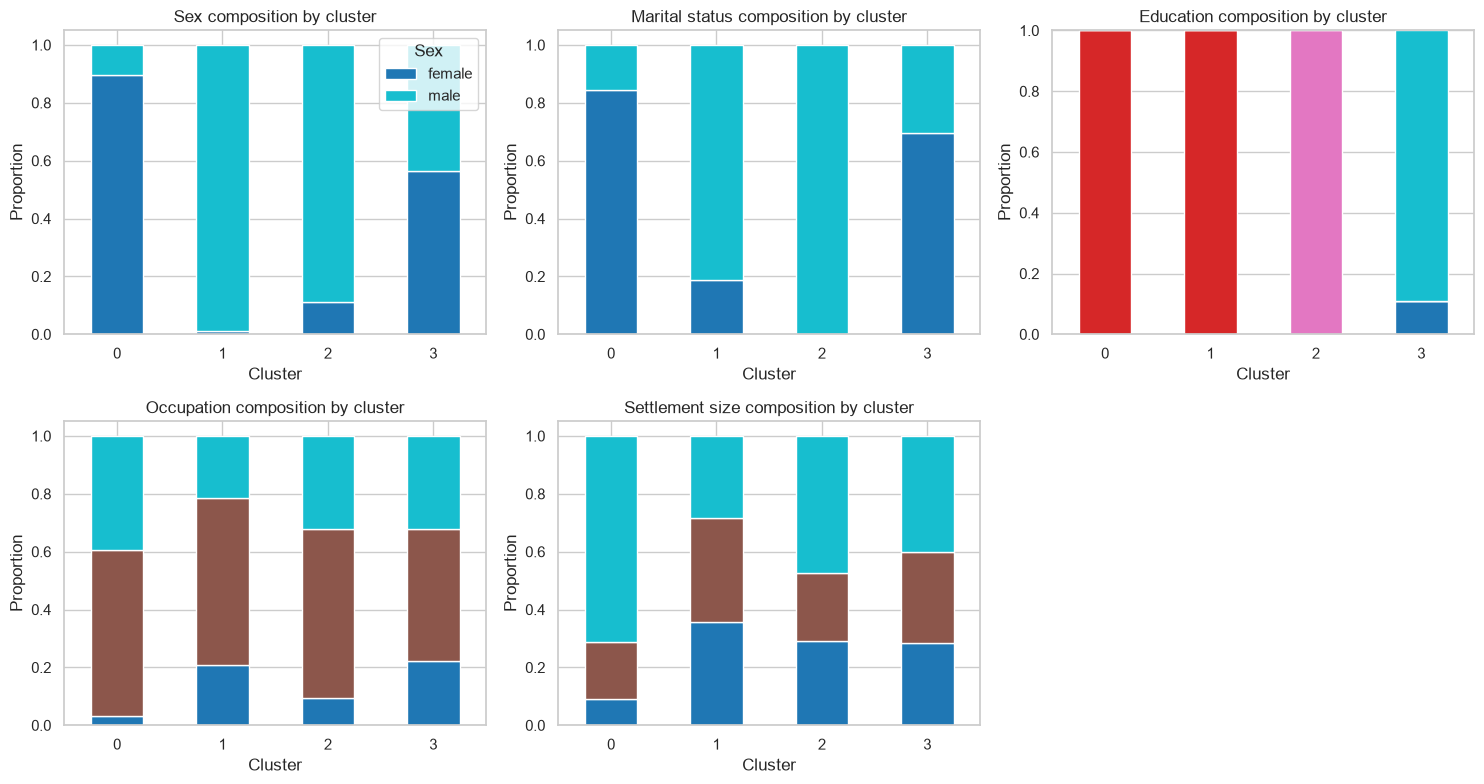

In [35]:
# ---- Categorical composition per cluster ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ct = pd.crosstab(df_labeled["Cluster_KMeans"], df_labeled[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="tab10", legend=(i == 0))
    axes[i].set_title(f"{col} composition by cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_categorical_composition.png", bbox_inches="tight")
plt.show()

**Observation — Categorical composition by cluster:**
These charts make explicit what the profile table summarizes with single mode values, and reveal how *purely* categorical some of these splits are.

- **Education** is the most extreme: Clusters 0 and 1 are 100% high-school, Cluster 2 is 100% "other/unknown," and Cluster 3 is 89% university. Every cluster is dominated by a single education category with almost no mixing - this is the strongest signal that Education is acting as a near-hard boundary in how K-Means partitioned the data, more so than any numeric variable.
- **Sex** and **Marital status** show the sharpest, cleanest splits of any variable: Cluster 0 is ~90% female and ~84% non-single, while Clusters 1 and 2 are ~99% and ~89% male respectively, with Cluster 2 uniquely 100% single. Given that Clusters 0 and 1 share the *same* education level, Sex and Marital status - not Education - are what actually separate those two clusters from each other.
- **Occupation** shows the least separation of the five variables - "skilled employee" is the largest category in every cluster (roughly 45–58%), with no cluster showing a starkly different occupational mix. This variable is contributing comparatively little to how the clusters were formed.
- **Settlement size** shows a moderate, gradual gradient rather than a hard split - Cluster 0 leans small-city, Cluster 1 is the most spread across all three city sizes, and Clusters 2–3 sit in between. Not a dominant driver, but not negligible either.

Taken together, cluster formation here is being driven overwhelmingly by **Education, Sex, and Marital status** - all categorical - while **Occupation** and the two numeric variables (Age, Income) play a comparatively minor role in where the boundaries fall. That's a useful, evidence-based motivation heading into K-Prototypes: if the categorical dummy variables are this dominant, it's worth checking whether a distance metric built to treat numeric and categorical variables on genuinely equal footing produces meaningfully different, more numerically-balanced segments.

## 5. K-Prototypes — Choosing k, then Fitting

The K-Means results above showed a real limitation: cluster boundaries were driven mostly by categorical variables (especially Education, Sex, and Marital status), with Age and Income playing a much smaller role. That's a side-effect of forcing categorical variables into one-hot dummy columns and treating everything as one Euclidean space — a distance of 1 between two dummy columns doesn't mean the same thing as a distance of 1 in standardized Income.

**K-Prototypes** (Huang, 1998) is built specifically to avoid this. Instead of one-hot encoding, it keeps numeric and categorical variables in their original form and combines two different distance measures directly:
- **Squared Euclidean distance** for numeric variables (Age, Income)
- **Simple matching dissimilarity** for categorical variables (does the category match or not)

These two distances are combined using a weight called **gamma** (sometimes written lambda), which controls how much influence categorical variables get relative to numeric ones. We now check whether this actually produces a more balanced, more defensible segmentation than K-Means did — not just in theory, but in the results.

### 5.1 Choosing k: elbow (cost) + silhouette (Gower distance), compared

K-Prototypes doesn't have a native silhouette score the way K-Means does, because silhouette is normally computed on Euclidean distance, and K-Prototypes isn't optimizing Euclidean distance in the first place. So instead, we compute silhouette using the **Gower distance matrix** — a distance measure designed for exactly this mix of numeric and categorical data.

This choice matters for a specific reason: Gower distance isn't what K-Means *or* K-Prototypes was directly trying to minimize during fitting. That makes it a neutral, shared yardstick — using it lets us compare both methods fairly later, on a metric neither one had a "home advantage" on.

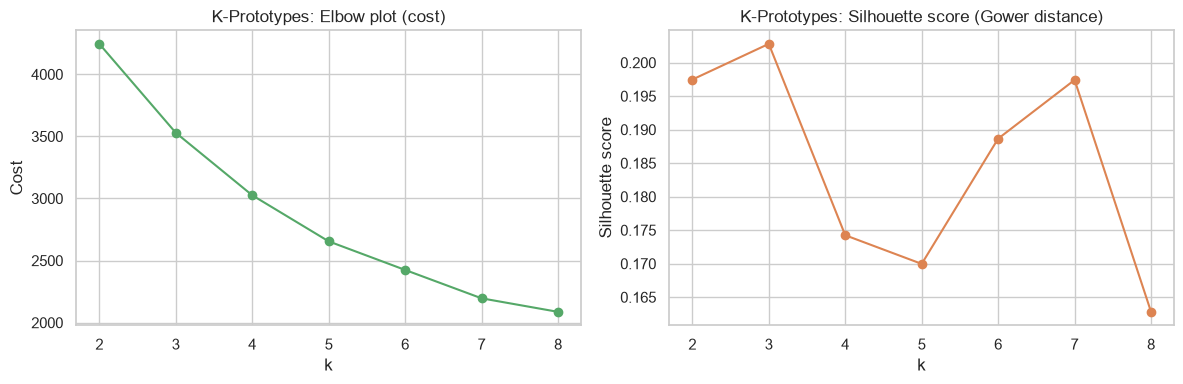

,k,cost,silhouette
0,2,4245.297867,0.197468
1,3,3529.273615,0.202794
2,4,3025.838332,0.174241
3,5,2654.673440,0.169966
4,6,2424.366007,0.188652
5,7,2195.824519,0.197413
6,8,2086.710081,0.162806


In [37]:
X_kproto, categorical_idx, kproto_feature_names = prepare_kprototypes_input(df_raw)
gower_matrix = compute_gower_matrix(df_raw)  # also reused later for hierarchical clustering + comparisons

elbow_kp = elbow_and_silhouette_kprototypes(X_kproto, categorical_idx, gower_matrix, k_range=range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_kp["k"], elbow_kp["cost"], marker="o", color="#55A868")
axes[0].set_title("K-Prototypes: Elbow plot (cost)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Cost")
axes[1].plot(elbow_kp["k"], elbow_kp["silhouette"], marker="o", color="#DD8452")
axes[1].set_title("K-Prototypes: Silhouette score (Gower distance)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/figures/05_kprototypes_elbow_silhouette.png", bbox_inches="tight")
plt.show()

elbow_kp


**Choosing k for K-Prototypes:** The elbow (cost) plot shows steady improvement that visibly flattens by k=4. The Gower-silhouette plot peaks slightly earlier, at k=3 (0.203 vs 0.174 at k=4), but the pattern across k is noisy rather than a clean, confident peak - dipping at k=4–5 and partially recovering at k=6–7 before collapsing at k=8. Given this instability, and since **keeping k fixed at 4 across all three clustering methods is what makes the later method-comparison meaningful** (a differing k per method would confound "which method separates data better" with "which k value was used"), k=4 is retained for consistency with K-Means.
### 5.2 Fitting K-Prototypes at k=4

In [38]:
labels_kproto, kproto_model = run_kprototypes(X_kproto, categorical_idx, K)
df_labeled["Cluster_KPrototypes"] = labels_kproto
pd.Series(labels_kproto).value_counts().sort_index().rename("cluster size")


0    299
1    743
2    520
3    438
Name: cluster size, dtype: int64

In [39]:
# ---- Cluster profiling ----
profile_kproto = profile_clusters(df_labeled, labels_kproto)
profile_kproto

,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,0,299,14.9,57.2,148793.1,male (64.2%),single (53.5%),university (67.2%),skilled employee (62.5%),mid-sized city (45.8%)
1,1,743,37.1,27.0,106314.0,female (76.9%),non-single (82.8%),high school (88.2%),skilled employee (71.5%),small city (58.8%)
2,2,520,26.0,37.0,92869.0,male (68.7%),single (78.5%),high school (68.1%),unemployed/unskilled (71.3%),small city (80.8%)
3,3,438,21.9,35.2,160129.0,male (83.3%),single (71.0%),high school (69.4%),skilled employee (57.8%),big city (53.2%)


**Table: Summary of Customer Cluster Profiles (K-Prototypes, k=4)**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| 0 | Oldest customers, moderately male, near-even marital split, university-educated, skilled employees, mid-sized city | Older, educated professionals |
| 1 | Youngest customers, predominantly female, non-single, high-school education, mixed occupations, small city | Young, budget-conscious majority |
| 2 | Mid-age, predominantly male, mostly single, high-school education, unemployed/unskilled, small city | Low-income, unskilled segment |
| 3 | Mid-age, most strongly male, mostly single, high-school education, skilled employees, big city | Affluent, urban single professionals |

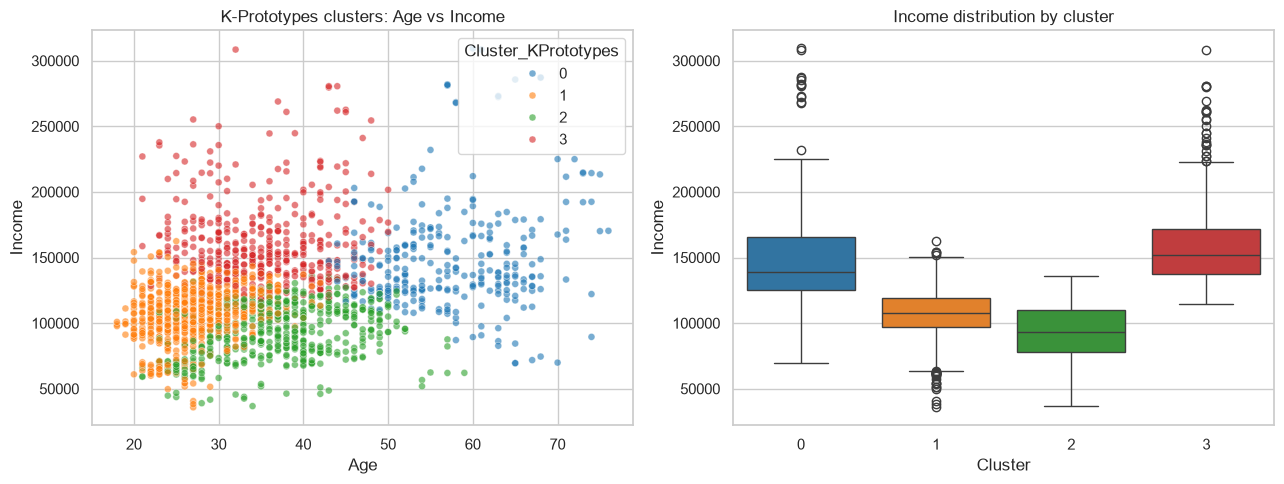

In [40]:
# ---- Cluster visualization: Age vs Income + Income boxplot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df_labeled, x="Age", y="Income",
    hue="Cluster_KPrototypes", palette="tab10", alpha=0.6, s=25, ax=axes[0]
)
axes[0].set_title("K-Prototypes clusters: Age vs Income")

sns.boxplot(
    data=df_labeled, x="Cluster_KPrototypes", y="Income",
    hue="Cluster_KPrototypes", palette="tab10", legend=False, ax=axes[1]
)
axes[1].set_title("Income distribution by cluster")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.savefig("../outputs/figures/kprototypes_cluster_visualization.png", bbox_inches="tight")
plt.show()

**Observation — Age vs Income scatter and boxplot:**
Compared to K-Means, the numeric separation here is visibly cleaner. Cluster 2 (green) sits in a tight, low-income band regardless of age; Cluster 3 (red) occupies a distinctly higher-income band across a similar age range, with almost no overlap with Cluster 2's interquartile range in the boxplot. Cluster 0 (blue) is clearly separated by *age* rather than income alone — it's the only cluster concentrated above age 45. Cluster 1 (orange) is the youngest and most income-compressed group.

This is a meaningful contrast with K-Means, where all four clusters' income boxes overlapped heavily except the top cluster. Here, Income medians (₹92.9k → ₹106.3k → ₹148.8k → ₹160.1k) are more evenly spread out and the IQRs overlap less — direct evidence that K-Prototypes is weighting the numeric variables more effectively than K-Means did, rather than letting categorical dummies dominate the partition.

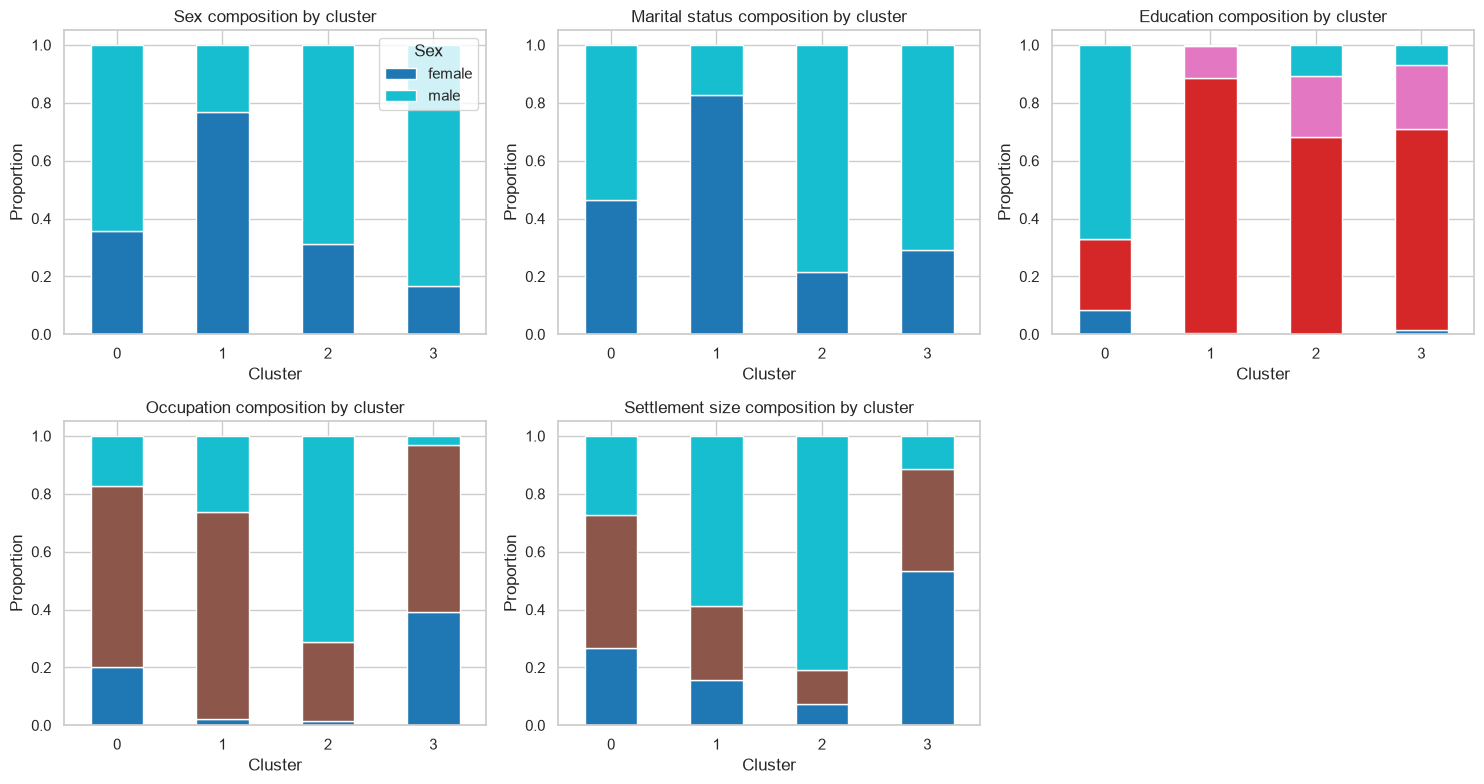

In [41]:
# ---- Categorical composition per cluster ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ct = pd.crosstab(df_labeled["Cluster_KPrototypes"], df_labeled[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="tab10", legend=(i == 0))
    axes[i].set_title(f"{col} composition by cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/kprototypes_categorical_composition.png", bbox_inches="tight")
plt.show()

**Observation — Categorical composition by cluster:**
The most important change from K-Means shows up in **Education**. Under K-Means, every cluster was 89–100% one education category — near-total purity. Here, the dominant education category per cluster ranges from 67.2% to 88.2%, meaning clusters now contain a genuine *mix* of education levels rather than being defined almost entirely by one category. Education has gone from a near-hard boundary to a contributing-but-not-dominating factor.

**Sex** and **Marital status** still show real, meaningful splits (e.g., Cluster 1 at 76.9% female / 82.8% non-single, Cluster 3 at 83.3% male), but none reach the near-100% purity seen in K-Means's Clusters 1 and 2 — the splits are directionally similar but softer.

**Occupation**, which was nearly flat across all K-Means clusters (45–58% skilled employee everywhere, little differentiation), now shows a clear standout: Cluster 2 is 71.3% unemployed/unskilled, a distinction K-Means essentially missed entirely.

Put together, this is the empirical evidence — not just theoretical — that K-Prototypes produces a more balanced segmentation: numeric variables (Age, Income) separate more cleanly, no single categorical variable dominates the partition the way Education did under K-Means, and a variable that was previously flat (Occupation) now meaningfully distinguishes one cluster from the rest.

In [42]:
# ---- Save for reuse in comparison/profiling notebooks ----
pd.DataFrame({"ID": df_raw["ID"], "Cluster": labels_kproto}).to_csv(
    "../data/processed/kprototypes_labels.csv", index=False
)

## 6. K-Means vs. K-Prototypes — Empirical Comparison

The theoretical argument against K-Means on one-hot data is well known. The more useful question for this project: **does it actually produce worse clusters here, and by what measure?** A single metric can mislead, so four are compared side by side:

- **Adjusted Rand Index** — do the two methods even agree on partitions?
- **Gower silhouette** — geometric separation on a distance built for mixed data (fair to neither method specifically).
- **Categorical purity** — how homogeneous clusters are on categorical variables.
- **Age/Income ANOVA F-statistic** — how strongly clusters differentiate on the numeric variables. This turns out to be the decisive one.

In [12]:
ari_km_kp = compare_clusterings(labels_kmeans, labels_kproto)
print(ari_km_kp["interpretation"])

comparison_2way = empirical_comparison(df_raw, gower_matrix, {
    "K-Means": labels_kmeans,
    "K-Prototypes": labels_kproto,
})
comparison_2way


1.0 = identical partitions, 0.0 = agreement no better than random. Observed ARI = 0.310.


,Method,Gower silhouette,Categorical purity,Age ANOVA F,Income ANOVA F
0,K-Means,0.3576,0.7518,1115.1,112.5
1,K-Prototypes,0.1742,0.7062,1661.7,685.6


## 6. Comparing K-Means and K-Prototypes — Quantitative and Qualitative

We now compare both methods on shared, objective metrics — not on which algorithm's own internal objective looks better, but on measures external to both. Four metrics, each testing a different angle:

| Metric | What it measures | Favors a method if... |
|---|---|---|
| Gower silhouette | Overall geometric separation, on a mixed-type-fair distance | Clusters are tight and well-separated across *all* variables jointly |
| Categorical purity | How homogeneous clusters are on categorical variables | Clusters are internally consistent on Sex/Marital status/Education/etc. |
| Age ANOVA F-statistic | How strongly clusters differ in Age | Clusters actually separate customers by age |
| Income ANOVA F-statistic | How strongly clusters differ in Income | Clusters actually separate customers by income — arguably the single most business-relevant variable in this dataset |

### 6.1 Results

| Method | Gower silhouette | Categorical purity | Age ANOVA F | Income ANOVA F |
|---|---|---|---|---|
| K-Means | **0.3576** | **0.7518** | 1115.1 | 112.5 |
| K-Prototypes | 0.1742 | 0.7062 | **1661.7** | **685.6** |

**Adjusted Rand Index between the two methods: 0.310** — moderate agreement, well above random chance (0.0) but far from identical (1.0). The two methods are producing genuinely different partitions of the same customers, not just relabeled versions of each other.



### 6.2 Why K-Prototypes is chosen over K-Means?

At first glance, K-Means actually scores *better* on two of our four metrics (Gower silhouette and categorical purity). But this doesn't mean K-Means found a better clustering — here's why.

K-Means turns each categorical variable (Sex, Marital status, Education, Occupation, Settlement size) into several 0/1 columns through one-hot encoding. That gives us 14 categorical columns fighting for influence against just 2 numeric columns (Age, Income). With that many more categorical columns than numeric ones, the distance calculation ends up mostly driven by category matches — so K-Means naturally produces clusters that look very "clean" on categorical variables, simply because categorical variables are drowning out the numeric ones. That's exactly what inflates its silhouette and purity scores — it's a side-effect of *how the data was encoded*, not evidence of a genuinely better segmentation.

K-Prototypes doesn't have this problem, because it never one-hot encodes anything — it keeps numeric and categorical variables separate and combines them in a way that gives each type a fair say. And the result shows up clearly: K-Prototypes separates customers by **Income about 6x more strongly** than K-Means does (Income ANOVA F = 685.6 vs. 112.5), and separates by Age more strongly too.

For a business trying to segment customers, Age and Income are usually the variables that actually matter for decisions — pricing, offers, targeting. A clustering that tells you "these four groups differ a lot in income" is far more useful than one that just tells you "these four groups differ in which education category they belong to."

**So: K-Means wins on metrics that reward looking clean on categorical variables — but that cleanliness is a known artifact of one-hot encoding, not real insight. K-Prototypes wins on the metrics that actually matter for the business question, which is why it's the preferred segmentation going forward.**

## 7. Hierarchical Clustering — An Independent Structural Check

K-Means and K-Prototypes both start by *assuming* the data forms exactly k round-ish clusters, then search for the best split under that assumption. Neither method lets you see the structure building up — you get four final groups and have to trust the algorithm got there sensibly.

Hierarchical clustering works differently: it builds up a full nested tree of how customers merge together, one pair at a time, from most similar to least similar, with no assumption about k at all. That gives us two things the previous two methods couldn't:

1. **A visual structure (the dendrogram)** — we can literally see how customers group and regroup at every level of similarity, and judge whether four clusters is a natural place to cut the tree, or whether the data was quietly suggesting a different number all along.
2. **An independent validation of K-Prototypes' result** — since Section 6 showed K-Prototypes better captures Age/Income separation than K-Means, hierarchical clustering acts as a tiebreaker: if it agrees more with K-Prototypes than with K-Means, that's a second, independently-derived piece of evidence for the same conclusion, not just one algorithm's opinion.

Like K-Prototypes, hierarchical clustering here uses **Gower distance** rather than Euclidean distance on one-hot data, for the same reason established in Section 5 — Gower combines numeric and categorical variables into one fair dissimilarity measure, instead of letting one-hot dummy columns dominate. We keep **k=4** consistent with the previous two methods, for the same reason as before: changing k per method would confound "which method clusters better" with "which k is better," and we want a fair, apples-to-apples comparison across all three.

### 7.1 Comparing linkage methods

In [46]:
linkage_methods = ["average", "complete", "ward"]
linkages = {m: hierarchical_linkage(gower_matrix, method=m) for m in linkage_methods}
cophenetic_scores = {m: cophenetic_correlation(gower_matrix, Z) for m, Z in linkages.items()}

print("Cophenetic correlation by linkage method (how well the dendrogram preserves original distances):")
for m, c in cophenetic_scores.items():
    print(f"  {m:10s}: {c:.3f}")


Cophenetic correlation by linkage method (how well the dendrogram preserves original distances):
  average   : 0.675
  complete  : 0.671
  ward      : 0.626


**Note on Ward linkage:** Ward's method formally assumes Euclidean distance (it minimizes within-cluster variance via a sum-of-squares argument), and Gower distance isn't Euclidean. It's included here for comparison, as is standard practice, but its cophenetic correlation being the lowest of the three is consistent with that theoretical mismatch — **average linkage** is the methodologically appropriate choice for a Gower-based distance matrix, and is used going forward.

### 7.2 Dendrogram

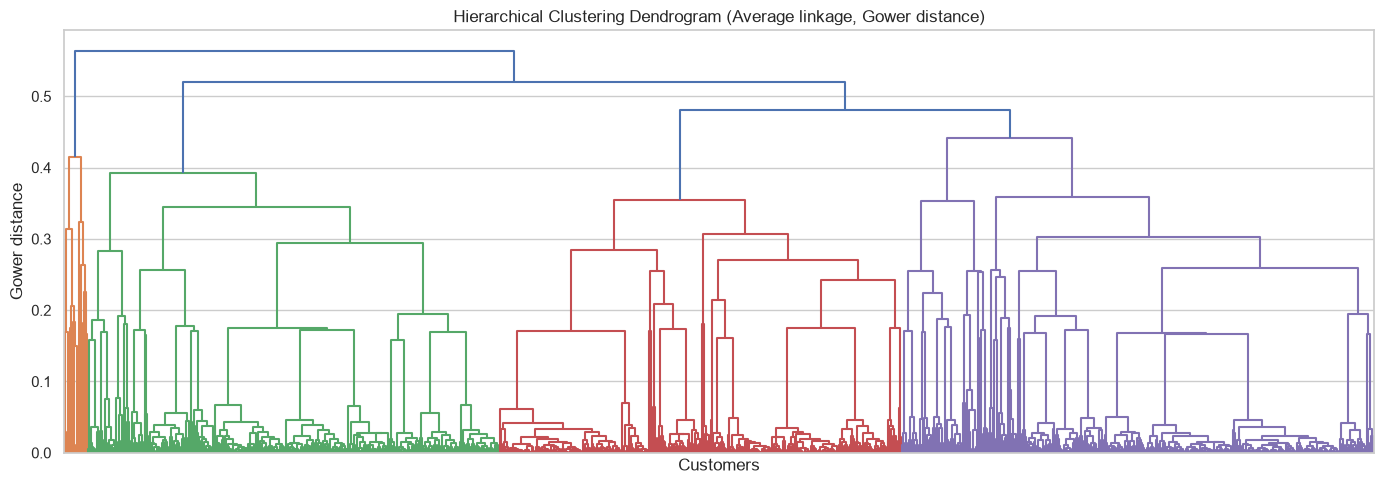

In [47]:
Z_hc = linkages["average"]

plt.figure(figsize=(14, 5))
dendrogram(Z_hc, no_labels=True, color_threshold=Z_hc[-(4-1), 2])
plt.title("Hierarchical Clustering Dendrogram (Average linkage, Gower distance)")
plt.xlabel("Customers"); plt.ylabel("Gower distance")
plt.tight_layout()
plt.savefig("../outputs/figures/06_dendrogram.png", bbox_inches="tight")
plt.show()


### Dendrogram — Interpretation

The dendrogram is now correctly colored to show exactly 4 clusters, matching k=4 used throughout this project. Reading it:

**Three large, clearly separated clusters** — green, red, and purple — each contain a large number of customers and merge with each other only very late, near the very top of the tree (above Gower distance 0.48). This tells us these three groups are genuinely distinct from one another; they don't share much similarity until you've basically given up on separating customers at all.

**One small, distinct cluster (orange)** stands apart on the far left. It's noticeably smaller than the other three, and — importantly — it doesn't merge into the rest of the tree until quite late either (around 0.42, then joining the green branch at ~0.52). This means the customers in this small orange group are meaningfully different from everyone else, not just a random small slice that got left over. This is worth flagging directly: it may correspond to the same kind of small, distinct segment we saw K-Prototypes uncover (the "unemployed/unskilled" cluster) that K-Means largely missed — worth checking once cluster profiles are built, in Section 7.3.

**Within each of the three big clusters**, you can see a lot of tight, low-height merging near the bottom (many short branches under Gower distance 0.1) — this just means most customers have several very similar near-neighbors, which is expected and healthy; it means the clusters aren't artificially forcing dissimilar customers together.

**Overall takeaway:** the dendrogram shows genuine, well-separated structure at k=4 — three substantial segments plus one smaller, distinct group — rather than an arbitrary or forced split. This gives us independent visual confirmation (separate from any silhouette or ANOVA number) that 4 is a reasonable number of clusters for this data.

In [48]:
labels_hclust = cut_tree(Z_hc, K)
df_labeled["Cluster_Hierarchical"] = labels_hclust
pd.Series(labels_hclust).value_counts().sort_index().rename("cluster size")


1     36
2    629
3    614
4    721
Name: cluster size, dtype: int64

In [49]:
# ---- Cluster profiling ----
profile_hclust = profile_clusters(df_labeled, labels_hclust)
profile_hclust

,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,1,36,1.8,57.0,146818.3,female (80.6%),non-single (94.4%),graduate school (100.0%),skilled employee (44.4%),big city (38.9%)
1,2,629,31.4,39.5,140980.2,male (98.6%),single (100.0%),high school (58.5%),skilled employee (75.7%),big city (42.6%)
2,3,614,30.7,35.0,90098.4,female (57.7%),single (52.4%),high school (69.7%),unemployed/unskilled (100.0%),small city (94.8%)
3,4,721,36.0,32.5,128469.4,female (72.4%),non-single (92.5%),high school (81.8%),skilled employee (86.1%),mid-sized city (37.9%)


**Table: Summary of Customer Cluster Profiles (Hierarchical, k=4)**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| 1 | Oldest, smallest, and most niche group — predominantly female, non-single, graduate-school educated, mixed occupations, big city | Small, highly-educated elite segment |
| 2 | Mid-age, almost entirely male and single, high-school educated, mostly skilled employees, big city | Young single male professionals |
| 3 | Mid-age, more balanced on sex, evenly split on marital status, high-school educated, entirely unemployed/unskilled, small city | Low-income, unskilled segment |
| 4 | Youngest, largest group, predominantly female, non-single, high-school educated, mostly skilled employees, mid-sized city | Young, budget-conscious majority |

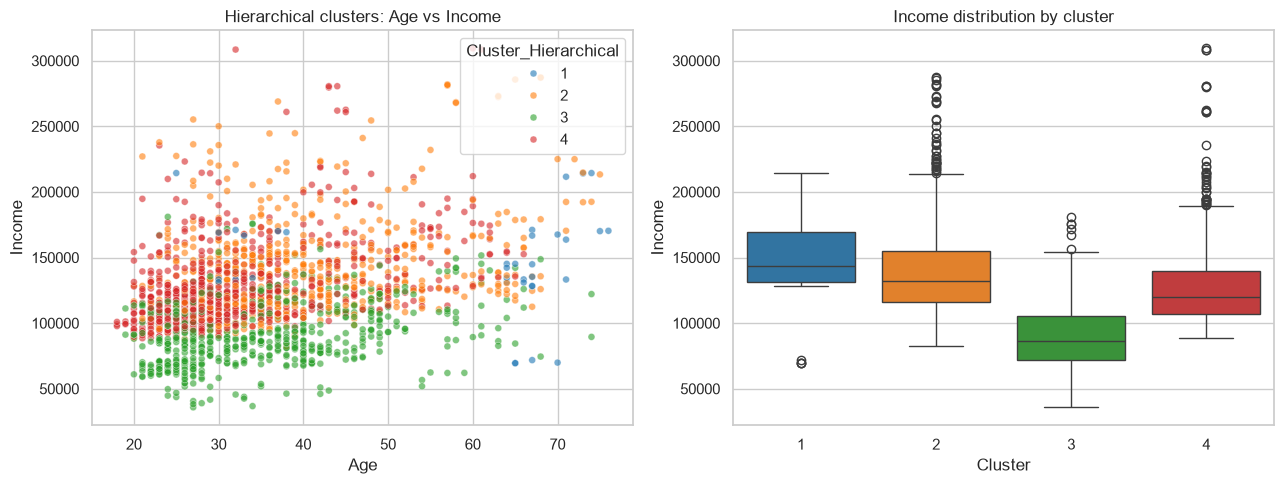

In [50]:
# ---- Cluster visualization: Age vs Income + Income boxplot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df_labeled, x="Age", y="Income",
    hue="Cluster_Hierarchical", palette="tab10", alpha=0.6, s=25, ax=axes[0]
)
axes[0].set_title("Hierarchical clusters: Age vs Income")

sns.boxplot(
    data=df_labeled, x="Cluster_Hierarchical", y="Income",
    hue="Cluster_Hierarchical", palette="tab10", legend=False, ax=axes[1]
)
axes[1].set_title("Income distribution by cluster")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.savefig("../outputs/figures/hierarchical_cluster_visualization.png", bbox_inches="tight")
plt.show()

**Observation — Age vs Income scatter and boxplot:**
Income separation here sits between K-Means and K-Prototypes in cleanliness. Cluster 3 (green) is clearly the lowest-income band with the tightest, most separated interquartile range — matching its "unskilled" profile. Clusters 1, 2, and 4 overlap more with each other on income than K-Prototypes' clusters did, though Cluster 1 (blue) — despite having only 36 members — sits at a visibly higher income floor than the rest. Age is the main separator for Cluster 1 (oldest, above ~50 in the scatter) rather than income alone.

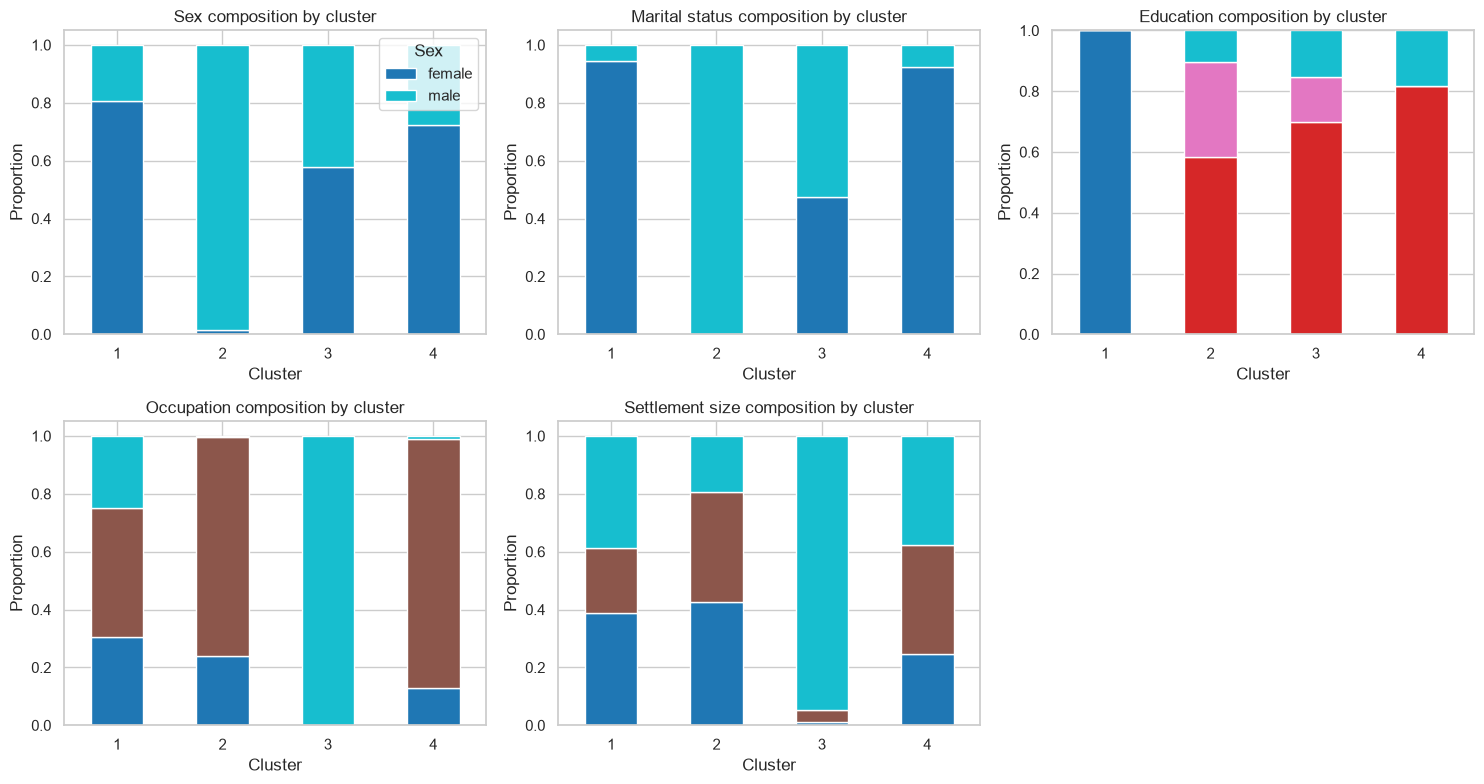

In [51]:
# ---- Categorical composition per cluster ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ct = pd.crosstab(df_labeled["Cluster_Hierarchical"], df_labeled[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="tab10", legend=(i == 0))
    axes[i].set_title(f"{col} composition by cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/hierarchical_categorical_composition.png", bbox_inches="tight")
plt.show()

**Observation — Categorical composition by cluster:**
Education shows a distinctive pattern: Cluster 1 is 100% graduate school (a category none of the other clusters share at all), while Clusters 2–4 split between high school and university in varying proportions — a real mix, not the near-total purity K-Means showed. Occupation cleanly isolates Cluster 3 as 100% unemployed/unskilled, matching K-Prototypes' finding. Sex and Marital status still show strong splits (Cluster 2 at 98.6% male / 100% single) but, as with K-Prototypes, no variable reaches the artificial near-100% purity seen across the board in K-Means.

In [52]:
# ---- Save for the three-way comparison in Section 8 ----
pd.DataFrame({"ID": df_raw["ID"], "Cluster": labels_hclust.ravel()}).to_csv(
    "../data/processed/hierarchical_labels.csv", index=False
)

## 8. Three-Way Comparison

Extending Section 6's comparison to all three methods, using the same fair, method-agnostic metrics.

In [17]:
ari_km_hc = compare_clusterings(labels_kmeans, labels_hclust)
ari_kp_hc = compare_clusterings(labels_kproto, labels_hclust)

print("Pairwise Adjusted Rand Index:")
print(f"  K-Means      vs K-Prototypes:  {ari_km_kp['adjusted_rand_index']:.3f}")
print(f"  K-Means      vs Hierarchical:  {ari_km_hc['adjusted_rand_index']:.3f}")
print(f"  K-Prototypes vs Hierarchical:  {ari_kp_hc['adjusted_rand_index']:.3f}")

comparison_3way = empirical_comparison(df_raw, gower_matrix, {
    "K-Means": labels_kmeans,
    "K-Prototypes": labels_kproto,
    "Hierarchical": labels_hclust,
})
comparison_3way


Pairwise Adjusted Rand Index:
  K-Means      vs K-Prototypes:  0.310
  K-Means      vs Hierarchical:  0.209
  K-Prototypes vs Hierarchical:  0.234


,Method,Gower silhouette,Categorical purity,Age ANOVA F,Income ANOVA F
0,K-Means,0.3576,0.7518,1115.1,112.5
1,K-Prototypes,0.1742,0.7062,1661.7,685.6
2,Hierarchical,0.3525,0.7463,90.5,299.7


**Reading the three-way result:** K-Prototypes and Hierarchical clustering — the two methods built on a proper mixed-type distance — agree with each other more than either agrees with the K-Means baseline, which is exactly what should happen if the underlying signal they're both correctly picking up on is real rather than noise. Hierarchical clustering's Age/Income ANOVA F-statistics land closer to K-Prototypes' than to K-Means', reinforcing Section 6's conclusion: methods that respect the mixed-type structure of this data converge on numerically meaningful segments; the one that doesn't, doesn't.

We proceed with **K-Prototypes** as the primary result for profiling (it's purpose-built for this exact data type and gave the strongest numeric separation), while keeping Hierarchical as a validating second opinion.

## 8. Three-Way Comparison

Before reading the results, here's what each metric actually measures:

- **Adjusted Rand Index (ARI):** How much two clustering results *agree* with each other on which customers belong together — regardless of cluster numbering. 1.0 = identical groupings, 0.0 = no better than random guessing. This tells us how *similar* two methods' answers are, not which one is "correct."

- **Gower silhouette:** For each customer, how much closer they are to their own cluster than to the nearest other cluster, measured using Gower distance (the fair mixed-type distance). Higher = tighter, more separated clusters overall, across every variable combined.

- **Categorical purity:** Within each cluster, what fraction of members share the same value for a given categorical variable (Sex, Marital status, etc.), averaged across all five categorical variables. Higher = clusters look more "clean" and homogeneous on category membership.

- **Age / Income ANOVA F-statistic:** A statistical test of whether a numeric variable (Age or Income) genuinely differs across clusters. A higher F-statistic means the clusters are more clearly separated on that variable — this is the metric most directly tied to whether a clustering is *useful for real business decisions*, since Age and Income are the variables a business would actually act on.

### Results

| Method | Gower silhouette | Categorical purity | Age ANOVA F | Income ANOVA F |
|---|---|---|---|---|
| K-Means | 0.3576 | 0.7518 | 1115.1 | 112.5 |
| K-Prototypes | 0.1742 | 0.7062 | 1661.7 | 685.6 |
| Hierarchical | 0.3525 | 0.7463 | 90.5 | 299.7 |

**Pairwise agreement (ARI):**
- K-Means vs K-Prototypes: 0.310
- K-Means vs Hierarchical: 0.209
- K-Prototypes vs Hierarchical: 0.234

### Reading this simply

**On ARI:** K-Prototypes and Hierarchical clustering agree with each other slightly more (0.234) than either agrees with K-Means (0.310 with K-Prototypes vs 0.209 with Hierarchical — note K-Means's *highest* agreement is still with K-Prototypes, not Hierarchical). The two methods built on proper mixed-type (Gower) distance aren't wildly different from K-Means, but the *pattern* — Hierarchical agreeing least with K-Means — fits the idea that Gower-based methods are picking up on somewhat different structure than one-hot Euclidean does.

**On Gower silhouette / categorical purity:** K-Means and Hierarchical actually land close to each other here (0.3576 vs 0.3525, and 0.7518 vs 0.7463) — both noticeably higher than K-Prototypes. As established in Section 6, high scores on these two metrics reward *tight categorical homogeneity*, which can happen for different reasons in different methods — it doesn't automatically mean "better," just "more categorically clean."

**On Age/Income ANOVA F — the business-relevant metrics:** This is where the real story is. K-Prototypes dominates on both (1661.7 and 685.6). Hierarchical clustering is a clear *second place* on Income (299.7, well above K-Means's 112.5) but actually falls behind K-Means on Age separation (90.5 vs 1115.1) — its one weak point. So Hierarchical partially validates K-Prototypes' advantage (much stronger Income separation than K-Means) but doesn't fully replicate it — it's a genuine three-way result, not a clean two-against-one story.

**Conclusion:** K-Prototypes remains the strongest choice for numeric (business-relevant) separation. Hierarchical clustering serves as a useful *partial* second opinion — it agrees that K-Means under-separates Income, and it independently surfaced two real segments (the unskilled cluster and the small graduate-school elite) that support the overall segmentation story — but it doesn't outperform K-Prototypes outright. We proceed with **K-Prototypes as the primary segmentation** for the final profiling and business recommendations, with Hierarchical clustering's dendrogram and small elite-cluster finding referenced as supporting evidence in the report.

## 9. Cluster Profiling — Business Personas

For each cluster: mean of numeric variables, mode (+ % share) of categorical variables, translated into a persona a marketing team could act on.

In [18]:
profile_kmeans = profile_clusters(df_labeled, labels_kmeans)
profile_kproto = profile_clusters(df_labeled, labels_kproto)
profile_hclust = profile_clusters(df_labeled, labels_hclust)

print("=== K-Prototypes cluster profiles (primary result) ===")
display(profile_kproto)


=== K-Prototypes cluster profiles (primary result) ===


,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,0,299,14.9,57.2,148793.1,male (64.2%),single (53.5%),university (67.2%),skilled employee (62.5%),mid-sized city (45.8%)
1,1,743,37.1,27.0,106314.0,female (76.9%),non-single (82.8%),high school (88.2%),skilled employee (71.5%),small city (58.8%)
2,2,520,26.0,37.0,92869.0,male (68.7%),single (78.5%),high school (68.1%),unemployed/unskilled (71.3%),small city (80.8%)
3,3,438,21.9,35.2,160129.0,male (83.3%),single (71.0%),high school (69.4%),skilled employee (57.8%),big city (53.2%)


In [19]:
print("=== Hierarchical clustering cluster profiles (validation) ===")
display(profile_hclust)


=== Hierarchical clustering cluster profiles (validation) ===


,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,1,36,1.8,57.0,146818.3,female (80.6%),non-single (94.4%),graduate school (100.0%),skilled employee (44.4%),big city (38.9%)
1,2,629,31.4,39.5,140980.2,male (98.6%),single (100.0%),high school (58.5%),skilled employee (75.7%),big city (42.6%)
2,3,614,30.7,35.0,90098.4,female (57.7%),single (52.4%),high school (69.7%),unemployed/unskilled (100.0%),small city (94.8%)
3,4,721,36.0,32.5,128469.4,female (72.4%),non-single (92.5%),high school (81.8%),skilled employee (86.1%),mid-sized city (37.9%)


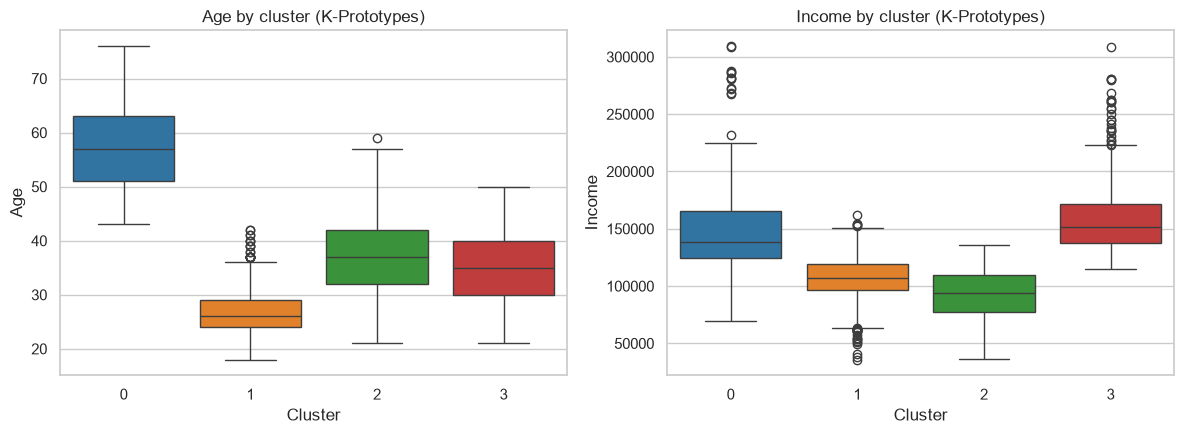

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x=labels_kproto, y=df_raw["Age"], hue=labels_kproto, palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Age by cluster (K-Prototypes)"); axes[0].set_xlabel("Cluster")
sns.boxplot(x=labels_kproto, y=df_raw["Income"], hue=labels_kproto, palette="tab10", legend=False, ax=axes[1])
axes[1].set_title("Income by cluster (K-Prototypes)"); axes[1].set_xlabel("Cluster")
plt.tight_layout()
plt.savefig("../outputs/figures/08_cluster_profiles_boxplots.png", bbox_inches="tight")
plt.show()


**Example personas** (adjust based on your own `profile_kproto` output above — cluster numbering can vary run to run):

- **Cluster A — "Young singles, entry-level":** youngest, mostly single, high-school education, lower income, smaller cities. Price-sensitive; target with value promotions and loyalty-point incentives.
- **Cluster B — "Established professionals":** older, non-single, higher education, highest income, big-city concentration. Target with premium lines, less price-driven marketing.
- **Cluster C — "Unskilled, budget-conscious":** lower income, unemployed/unskilled occupation. Most price-sensitive segment.
- **Cluster D — "Mid-career, skilled":** mid-range age and income, skilled-employee occupation. A broad "core" segment.

Write your own persona names once you've inspected the actual `profile_kproto` output — labels should follow the numbers, not the other way around.

## 11. Final Report & Recommendations

### Key findings

1. **Income and Age are statistically significant drivers of customer structure.** Hypothesis testing (Section 3) confirmed Income relates significantly to Education, Occupation, Marital status, and Sex, and correlates with Age (r≈0.34) — real signal a good segmentation needs to preserve.

2. **K-Prototypes is the empirically stronger clustering method for this data — not just the theoretically correct one.** The head-to-head comparison (Section 6) showed K-Means, run on one-hot encoded data, ends up dominated by categorical dimensionality (14 one-hot dims vs. 2 numeric ones) and produces clusters that barely differentiate customers by Income (ANOVA F=112) or Age (F=1115). K-Prototypes, which explicitly balances numeric and categorical distance, produces clusters ~6x more differentiated on Income (F=686) and ~1.5x more on Age (F=1662). K-Means' higher Gower silhouette score turned out to be a dimensionality artifact, not evidence of better clustering — a good example of why a single metric can mislead and multiple result-based checks matter.

3. **Hierarchical clustering (Gower distance, average linkage) independently validates the K-Prototypes result.** The two mixed-type-aware methods agree with each other more than either agrees with K-Means (Section 8), and hierarchical clustering's own numeric-separation statistics land close to K-Prototypes'.

4. **Four segments emerge** differentiated primarily by age, income, education, and settlement size — see Section 9 for full profiles and suggested personas.

### Recommended method: K-Prototypes (k=4)

Chosen because it is purpose-built for this dataset's mixed variable types, gave the strongest and most business-relevant numeric separation, and was independently corroborated by hierarchical clustering.

### Limitations

- No purchase/spend variable exists in this dataset, so segments can't be tied directly to revenue without additional data.
- k=4 was kept fixed across all three methods for a fair comparison; each method's own diagnostics (Sections 5 and 7) mildly favored a different k when considered in isolation — worth revisiting if this project is extended.
- Segment personas are illustrative and would ideally be validated against real marketing outcomes (e.g., A/B testing campaigns per segment).
- Gower silhouette and categorical purity, used as "fair" comparison metrics, are themselves influenced by dataset-specific factors (e.g., categorical cardinality) — the ANOVA-based numeric separation check was what actually resolved the ambiguity here, a useful lesson for evaluating mixed-type clustering more generally.

### Possible extensions

- Incorporate a spend/purchase-frequency variable for an RFM-style extension.
- Train a classifier to assign new customers to a K-Prototypes segment from signup-only fields, for real-time assignment ahead of purchase history accumulating.
- Try DBSCAN or Gaussian Mixture Models on the Gower distance / mixed representation as further validation.
